# Inspect the BAF60 computeMatrix result

Each row is one MACS2 summit that passed `q <= 0.05`. The first six columns describe the region; the remaining columns are the `log2(IP/Input)` signal in 20-bp bins around the summit center.

In [1]:
from pathlib import Path
import gzip, json
import pandas as pd

matrix_path = Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow/compute_matrix/BAF60.matrix.gz')
with gzip.open(matrix_path, 'rt') as f:
    metadata = json.loads(f.readline().removeprefix('@'))

bin_size = metadata['bin size'][0]
bin_starts = range(-metadata['upstream'][0], metadata['downstream'][0], bin_size)
columns = ['chrom', 'start', 'end', 'name', 'score', 'strand'] + [f'signal_{x}_{x + bin_size}' for x in bin_starts]
df = pd.read_csv(matrix_path, sep='\t', comment='@', header=None, names=columns)

print(df.columns.tolist())
df.head()

['chrom', 'start', 'end', 'name', 'score', 'strand', 'signal_-2000_-1980', 'signal_-1980_-1960', 'signal_-1960_-1940', 'signal_-1940_-1920', 'signal_-1920_-1900', 'signal_-1900_-1880', 'signal_-1880_-1860', 'signal_-1860_-1840', 'signal_-1840_-1820', 'signal_-1820_-1800', 'signal_-1800_-1780', 'signal_-1780_-1760', 'signal_-1760_-1740', 'signal_-1740_-1720', 'signal_-1720_-1700', 'signal_-1700_-1680', 'signal_-1680_-1660', 'signal_-1660_-1640', 'signal_-1640_-1620', 'signal_-1620_-1600', 'signal_-1600_-1580', 'signal_-1580_-1560', 'signal_-1560_-1540', 'signal_-1540_-1520', 'signal_-1520_-1500', 'signal_-1500_-1480', 'signal_-1480_-1460', 'signal_-1460_-1440', 'signal_-1440_-1420', 'signal_-1420_-1400', 'signal_-1400_-1380', 'signal_-1380_-1360', 'signal_-1360_-1340', 'signal_-1340_-1320', 'signal_-1320_-1300', 'signal_-1300_-1280', 'signal_-1280_-1260', 'signal_-1260_-1240', 'signal_-1240_-1220', 'signal_-1220_-1200', 'signal_-1200_-1180', 'signal_-1180_-1160', 'signal_-1160_-1140', '

,chrom,start,end,name,score,strand,signal_-2000_-1980,signal_-1980_-1960,signal_-1960_-1940,signal_-1940_-1920,...,signal_1800_1820,signal_1820_1840,signal_1840_1860,signal_1860_1880,signal_1880_1900,signal_1900_1920,signal_1920_1940,signal_1940_1960,signal_1960_1980,signal_1980_2000
0,Chr1,18198,18199,Chr1:18198-18199,.,.,1.286365,-1.160889,-1.090970,-2.855915,...,0.527894,-2.026494,-1.990087,-2.009924,-2.687595,-0.848202,-0.805408,0.823847,2.279115,2.613129
1,Chr1,55407,55408,Chr1:55407-55408,.,.,-3.612891,-3.801084,-1.290003,0.041870,...,2.130731,0.343619,0.259388,-1.094276,0.052656,0.648646,1.040096,-0.351086,-2.510989,-3.040448
2,Chr1,68637,68638,Chr1:68637-68638,.,.,-2.056055,0.216041,0.465677,-0.294441,...,-0.548647,-0.498082,-2.954983,0.037379,0.803995,1.093562,-0.934032,-2.554880,-2.735178,-2.908939
3,Chr1,108140,108141,Chr1:108140-108141,.,.,1.512905,1.506475,1.167860,0.960246,...,-3.073125,-3.078485,-3.283310,-1.316585,-1.281295,-0.313498,0.013062,0.038621,-1.373646,-2.779555
4,Chr1,136082,136083,Chr1:136082-136083,.,.,-1.547692,-0.681531,-0.740163,-1.818045,...,-0.475403,-0.072776,-1.304329,-2.251832,-0.476568,0.106841,2.175033,3.305939,2.869367,0.488440


## Summit-centered heatmap and meta profile

Keep all called summits. Rows are only sorted by their mean signal within 200 bp of the summit; no additional low-signal filtering is applied.

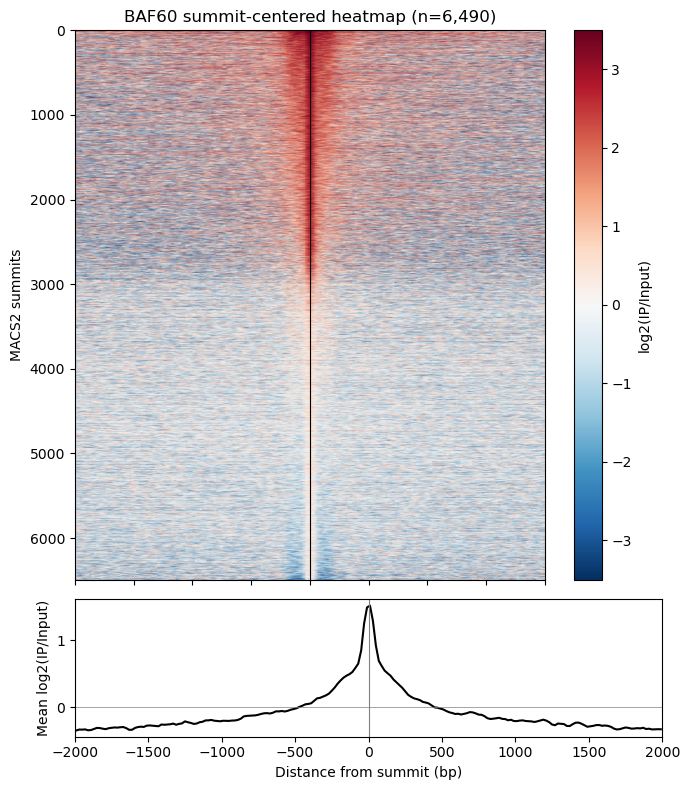

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-metadata['upstream'][0], metadata['downstream'][0], bin_size) + bin_size / 2
signal = df.iloc[:, 6:].to_numpy(float)
center = np.abs(x) <= 200
order = np.argsort(np.nanmean(signal[:, center], axis=1))[::-1]
color_limit = np.nanpercentile(np.abs(signal), 98)

fig, (ax_heatmap, ax_meta) = plt.subplots(2, 1, figsize=(7, 8), sharex=True, gridspec_kw={'height_ratios': [4, 1]})
image = ax_heatmap.imshow(signal[order], aspect='auto', cmap='RdBu_r', vmin=-color_limit, vmax=color_limit, extent=[-metadata['upstream'][0], metadata['downstream'][0], len(signal), 0])
ax_heatmap.axvline(0, color='black', lw=0.8)
ax_heatmap.set(ylabel='MACS2 summits', title=f'BAF60 summit-centered heatmap (n={len(signal):,})')
fig.colorbar(image, ax=ax_heatmap, label='log2(IP/Input)')

ax_meta.plot(x, np.nanmean(signal, axis=0), color='black')
ax_meta.axvline(0, color='grey', lw=0.8)
ax_meta.axhline(0, color='grey', lw=0.5)
ax_meta.set(xlabel='Distance from summit (bp)', ylabel='Mean log2(IP/Input)')
plt.tight_layout()

## Genomic annotation of MACS2 peaks

Use the full `narrowPeak` intervals and standard `gene`/`exon` features in the GTF. Categories are mutually exclusive with priority **Exon > Intron > strand-aware upstream 500 bp > Intergenic**. Genome fraction is the fraction of TAIR10 bases assigned by exactly the same rules.

In [3]:
gtf_path = Path('/data1/home/zhangzhhui03/workspace/reference/Araport11/Araport11_GTF_genes_transposons.20241001.gtf')
peak_path = Path('/data1/home/zhangzhhui03/workspace/projects/SWP73B/ChIP_ATAC_MNase_PRJNA351855/results/chip_workflow/macs2/BAF60/BAF60_peaks.narrowPeak')
chrom_sizes_path = Path('/data1/home/zhangzhhui03/workspace/repos/ChIP_workflow/config/TAIR10.chrom.sizes')

chrom_sizes = dict(pd.read_csv(chrom_sizes_path, sep='\t', header=None).itertuples(index=False, name=None))
gtf = pd.read_csv(gtf_path, sep='\t', comment='#', header=None, usecols=[0, 2, 3, 4, 6, 8],
                  names=['chrom', 'feature', 'start', 'end', 'strand', 'attribute'])
gtf['start'] -= 1  # GTF: 1-based inclusive -> BED/Python: 0-based half-open
gtf['gene_id'] = gtf['attribute'].str.extract(r'gene_id\s+([^;]+)', expand=False).str.replace(chr(34), '', regex=False)
genes = gtf[gtf['feature'] == 'gene']
exons = gtf[gtf['feature'] == 'exon']

# 0=Exon, 1=Intron, 2=Upstream 500, 3=Intergenic; later assignments have higher priority.
genome_label = {chrom: np.full(size, 3, dtype=np.uint8) for chrom, size in chrom_sizes.items()}
for chrom, start, end, strand in genes[['chrom', 'start', 'end', 'strand']].itertuples(index=False, name=None):
    if strand == '+':
        genome_label[chrom][max(0, start - 500):start] = 2
    else:
        genome_label[chrom][end:min(chrom_sizes[chrom], end + 500)] = 2
for chrom, start, end in genes[['chrom', 'start', 'end']].itertuples(index=False, name=None):
    genome_label[chrom][start:end] = 1
for chrom, start, end in exons[['chrom', 'start', 'end']].itertuples(index=False, name=None):
    genome_label[chrom][start:end] = 0

,Peaks,Peak %,Genome bp,Genome %
category,,,,
Exon,1609,24.79,57017315,47.65
Intron,112,1.73,18214322,15.22
Upstream 500,675,10.40,11085632,9.26
Intergenic,4094,63.08,33351365,27.87


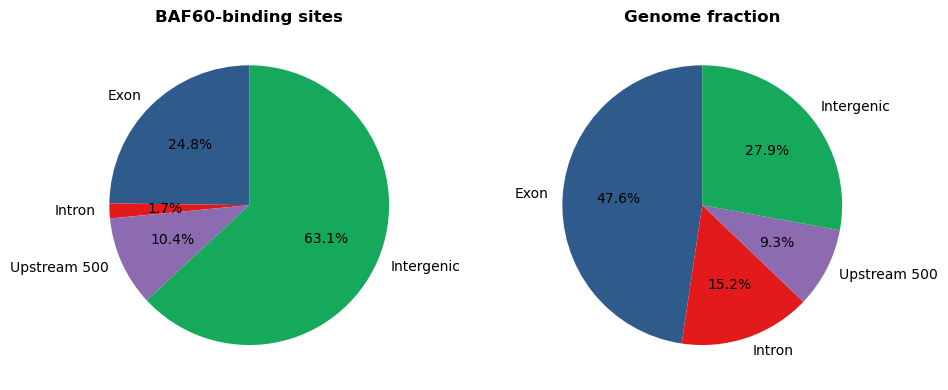

In [4]:
categories = ['Exon', 'Intron', 'Upstream 500', 'Intergenic']
peaks = pd.read_csv(peak_path, sep='\t', header=None, usecols=[0, 1, 2], names=['chrom', 'start', 'end'])
peaks['category'] = [categories[int(genome_label[c][s:e].min())] for c, s, e in peaks.itertuples(index=False, name=None)]
peak_counts = peaks['category'].value_counts().reindex(categories, fill_value=0)
genome_counts = sum((np.bincount(x, minlength=4) for x in genome_label.values()), np.zeros(4, dtype=np.int64))

summary = pd.DataFrame({'Peaks': peak_counts, 'Peak %': peak_counts / len(peaks) * 100,
                        'Genome bp': genome_counts, 'Genome %': genome_counts / genome_counts.sum() * 100})
display(summary.round(2))

colors = ['#2f5b8c', '#e31a1c', '#8c6bb1', '#16a85b']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, values, title in zip(axes, [peak_counts, genome_counts], ['BAF60-binding sites', 'Genome fraction']):
    ax.pie(values, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(title, fontweight='bold')
plt.tight_layout()

## Distance from intergenic peaks to the nearest TSS

Use each intergenic peak midpoint and the nearest gene TSS on the same chromosome. The signed distance follows transcription direction: negative is upstream and positive is downstream.

In [5]:
tss = genes[['chrom', 'start', 'end', 'strand', 'gene_id']].copy()
tss['tss'] = np.where(tss['strand'] == '+', tss['start'], tss['end'] - 1)
intergenic = peaks[peaks['category'] == 'Intergenic'].copy()
intergenic['midpoint'] = ((intergenic['start'] + intergenic['end']) // 2).astype(int)

nearest_parts = []
for chrom, peak_group in intergenic.groupby('chrom'):
    gene_group = tss[tss['chrom'] == chrom].sort_values('tss').reset_index(drop=True)
    positions = peak_group['midpoint'].to_numpy()
    tss_positions = gene_group['tss'].to_numpy()
    right = np.clip(np.searchsorted(tss_positions, positions), 0, len(tss_positions) - 1)
    left = np.clip(right - 1, 0, len(tss_positions) - 1)
    nearest = np.where(np.abs(tss_positions[right] - positions) < np.abs(tss_positions[left] - positions), right, left)
    selected = gene_group.iloc[nearest]
    nearest_parts.append(pd.DataFrame({'nearest_gene': selected['gene_id'].to_numpy(),
                                       'nearest_strand': selected['strand'].to_numpy(),
                                       'nearest_tss': selected['tss'].to_numpy()}, index=peak_group.index))

intergenic = intergenic.join(pd.concat(nearest_parts).sort_index())
genomic_delta = intergenic['midpoint'] - intergenic['nearest_tss']
intergenic['tss_distance_bp'] = np.where(intergenic['nearest_strand'] == '+', genomic_delta, -genomic_delta)
intergenic['abs_tss_distance_bp'] = intergenic['tss_distance_bp'].abs()
display(intergenic['abs_tss_distance_bp'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_frame().round(1))
intergenic.head()

,abs_tss_distance_bp
count,4094.0
mean,26964.2
std,41140.9
min,130.0
25%,1869.5
50%,7607.5
75%,34317.8
90%,82322.6
95%,133194.4
99%,176682.1


,chrom,start,end,category,midpoint,nearest_gene,nearest_strand,nearest_tss,tss_distance_bp,abs_tss_distance_bp
0,Chr1,18161,18242,Intergenic,18201,AT1G01030,-,13713,-4488,4488
1,Chr1,55370,55421,Intergenic,55395,AT1G01110,+,51952,3443,3443
2,Chr1,68628,68679,Intergenic,68653,AT1G01140,-,67773,-880,880
3,Chr1,108114,108182,Intergenic,108148,AT1G01260,+,108945,-797,797
11,Chr1,194876,194962,Intergenic,194919,AT1G01540,+,195644,-725,725


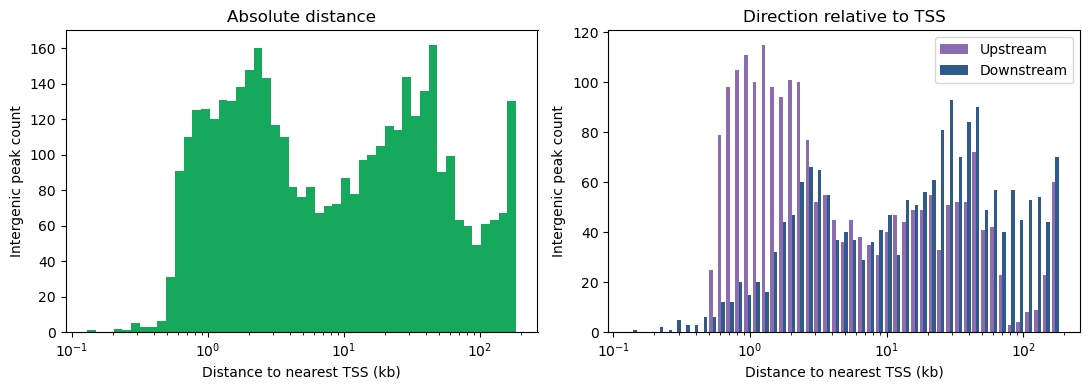

In [6]:
distance_kb = intergenic['abs_tss_distance_bp'] / 1000
bins = np.geomspace(distance_kb[distance_kb > 0].min(), distance_kb.max(), 50)
upstream_kb = distance_kb[intergenic['tss_distance_bp'] < 0]
downstream_kb = distance_kb[intergenic['tss_distance_bp'] >= 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(distance_kb, bins=bins, color='#16a85b')
axes[0].set_xscale('log')
axes[0].set(xlabel='Distance to nearest TSS (kb)', ylabel='Intergenic peak count', title='Absolute distance')
axes[1].hist([upstream_kb, downstream_kb], bins=bins, label=['Upstream', 'Downstream'], color=['#8c6bb1', '#2f5b8c'])
axes[1].set_xscale('log')
axes[1].set(xlabel='Distance to nearest TSS (kb)', ylabel='Intergenic peak count', title='Direction relative to TSS')
axes[1].legend()
plt.tight_layout()

## BAF60 profiles over genes and TSSs

Average `log2(IP/Input)` across all 33,326 GTF genes without signal filtering. Gene bodies are scaled to 5 kb; both matrices include 2-kb flanks.

In [7]:
def read_signal_matrix(path):
    with gzip.open(path, 'rt') as f:
        matrix_metadata = json.loads(f.readline().removeprefix('@'))
    matrix = pd.read_csv(path, sep='\t', comment='@', header=None)
    return matrix_metadata, matrix.iloc[:, 6:].to_numpy(float)

gene_body_path = matrix_path.parent.parent / 'compute_matrix_gene_body/BAF60.gene_body.matrix.gz'
tss_path = matrix_path.parent.parent / 'compute_matrix_TSS/BAF60.TSS.matrix.gz'
gene_body_metadata, gene_body_signal = read_signal_matrix(gene_body_path)
tss_metadata, tss_signal = read_signal_matrix(tss_path)
print('gene body:', gene_body_signal.shape, 'TSS:', tss_signal.shape)

gene body: (33326, 450) TSS: (33326, 200)


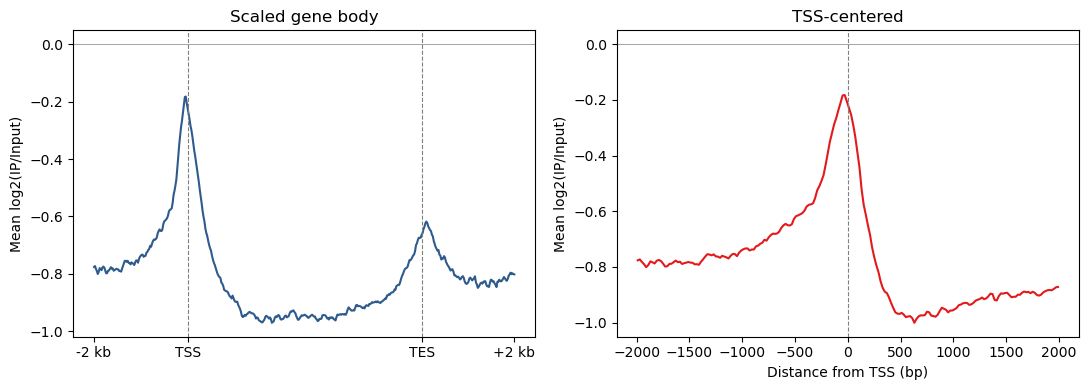

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

gene_profile = np.nanmean(gene_body_signal, axis=0)
axes[0].plot(gene_profile, color='#2f5b8c')
axes[0].axvline(100, color='grey', ls='--', lw=0.8)
axes[0].axvline(350, color='grey', ls='--', lw=0.8)
axes[0].axhline(0, color='grey', lw=0.5)
axes[0].set_xticks([0, 100, 350, 449], ['-2 kb', 'TSS', 'TES', '+2 kb'])
axes[0].set(ylabel='Mean log2(IP/Input)', title='Scaled gene body')

tss_x = np.arange(-2000, 2000, 20) + 10
axes[1].plot(tss_x, np.nanmean(tss_signal, axis=0), color='#e31a1c')
axes[1].axvline(0, color='grey', ls='--', lw=0.8)
axes[1].axhline(0, color='grey', lw=0.5)
axes[1].set(xlabel='Distance from TSS (bp)', ylabel='Mean log2(IP/Input)', title='TSS-centered')
plt.tight_layout()

## BAF60 peaks 涉及的基因数

按照链方向定义 **TSS 上游 1 kb 至 TES 下游 500 bp** 的目标基因区间。分别统计：（1）完整 MACS2 `narrowPeak` 与该区间发生任意重叠；（2）1 bp 的 MACS2 summit 落在该区间内。由于原文使用 HOMER 注释 peaks，这里也同时给出最近 TSS 的分配结果。

In [9]:
target_regions = genes[['chrom', 'start', 'end', 'strand', 'gene_id']].copy()
target_regions['region_start'] = np.maximum(np.where(target_regions['strand'] == '+',
                                                     target_regions['start'] - 1000,
                                                     target_regions['start'] - 500), 0)
target_regions['region_end'] = np.where(target_regions['strand'] == '+',
                                        target_regions['end'] + 500,
                                        target_regions['end'] + 1000)
summit_path = peak_path.with_name('BAF60_summits.bed')
summits = pd.read_csv(summit_path, sep='\t', header=None, usecols=[0, 1, 2],
                      names=['chrom', 'start', 'end'])

def count_overlaps(regions):
    hit_genes, hit_regions = set(), set()
    for chrom, chrom_genes in target_regions.groupby('chrom'):
        chrom_regions = regions[regions['chrom'] == chrom].sort_values('start')
        starts = chrom_regions['start'].to_numpy()
        ends = chrom_regions['end'].to_numpy()
        indices = chrom_regions.index.to_numpy()
        for gene in chrom_genes.itertuples():
            stop = np.searchsorted(starts, gene.region_end)
            overlaps = indices[:stop][ends[:stop] > gene.region_start]
            if len(overlaps):
                hit_genes.add(gene.gene_id)
                hit_regions.update(overlaps)
    return len(hit_regions), len(hit_genes)

full_peak_hits, full_peak_genes = count_overlaps(peaks)
summit_hits, summit_genes = count_overlaps(summits)

nearest_genes = set()
for chrom, chrom_summits in summits.groupby('chrom'):
    chrom_tss = tss[tss['chrom'] == chrom].sort_values('tss').reset_index(drop=True)
    positions = chrom_summits['start'].to_numpy()
    tss_positions = chrom_tss['tss'].to_numpy()
    right = np.clip(np.searchsorted(tss_positions, positions), 0, len(tss_positions) - 1)
    left = np.clip(right - 1, 0, len(tss_positions) - 1)
    nearest = np.where(np.abs(tss_positions[right] - positions) <
                       np.abs(tss_positions[left] - positions), right, left)
    nearest_genes.update(chrom_tss.iloc[nearest]['gene_id'])

paper_peaks, paper_genes = 5853, 3729
comparison = pd.DataFrame({
    '统计定义': ['原文（HOMER）', '完整 narrowPeak 与区间重叠',
                 'summit 落在区间内', '最近 TSS'],
    'peak 总数': [paper_peaks, len(peaks), len(summits), len(summits)],
    '区间内 peak/summit 数': [np.nan, full_peak_hits, summit_hits, len(summits)],
    '涉及的不同基因数': [paper_genes, full_peak_genes, summit_genes, len(nearest_genes)]
})
comparison['相对原文的基因数差值'] = comparison['涉及的不同基因数'] - paper_genes
display(comparison)
print(f'当前 peak 数相对原文：{len(peaks) - paper_peaks:+,}（{(len(peaks) / paper_peaks - 1) * 100:+.1f}%）')
print(f'完整 peak 区间涉及基因数相对原文：{full_peak_genes - paper_genes:+,}（{(full_peak_genes / paper_genes - 1) * 100:+.1f}%）')

,统计定义,peak 总数,区间内 peak/summit 数,涉及的不同基因数,相对原文的基因数差值
0,原文（HOMER）,5853,NaN,3729,0
1,完整 narrowPeak 与区间重叠,6490,2542.0,2805,-924
2,summit 落在区间内,6490,2472.0,2589,-1140
3,最近 TSS,6490,6490.0,2593,-1136


当前 peak 数相对原文：+637（+10.9%）
完整 peak 区间涉及基因数相对原文：-924（-24.8%）


### 结果总结

- 当前分析检出 **6,490 个显著 peaks**，原文为 **5,853 个**；当前多 637 个（**+10.9%**）。因此 peak 总数与原文相差不远，并不支持简单的峰检出不足。
- 按照考虑链方向的 `TSS 上游 1 kb` 至 `TES 下游 500 bp` 区间，**2,542 个 peaks 与 2,805 个基因重叠**。相比原文的 3,729 个目标基因少 **924 个（-24.8%）**。这些基因占当前 Araport11 GTF 中 33,326 个基因的 8.4%。
- 使用更严格的 summit 落入区间定义时，**2,472 个 summits 落在 2,589 个基因内**。将每个 summit 分配给最近 TSS，可得到 **2,593 个不同基因**。
- 因此主要差异不是检出的 peaks 太少。我们的 peaks 涉及的不同基因更少，说明它们更集中地重复分布在部分基因附近，或者更多位于所定义基因区间以外。
- 目前还不是完全同口径比较：原文使用 HOMER 和 TAIR10 做 peak 注释，我们的主要统计则使用明确的区间重叠规则和当前 Araport11 GTF。GEO 仅提供作者处理后的 WIG 轨道，没有作者的 peak BED，因此无法直接按我们的区间规则重新计算原文的 3,729 个基因。

原文：[Jégu 等，Genome Biology（2017）](https://doi.org/10.1186/s13059-017-1246-7)；数据：[GEO GSE89346](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE89346)。